In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv('creditScore.csv')

# EDA

In [6]:
df.head(5)

,Unnamed: 0,default,student,balance,income
0,1,No,No,729.526495,44361.62507
1,2,No,Yes,817.180407,12106.13470
2,3,No,No,1073.549164,31767.13895
3,4,No,No,529.250605,35704.49394
4,5,No,No,785.655883,38463.49588


In [8]:
df.shape

(10000, 5)

In [10]:
df.describe

<bound method NDFrame.describe of       Unnamed: 0 default student      balance       income
0              1      No      No   729.526495  44361.62507
1              2      No     Yes   817.180407  12106.13470
2              3      No      No  1073.549164  31767.13895
3              4      No      No   529.250605  35704.49394
4              5      No      No   785.655883  38463.49588
...          ...     ...     ...          ...          ...
9995        9996      No      No   711.555020  52992.37891
9996        9997      No      No   757.962918  19660.72177
9997        9998      No      No   845.411989  58636.15698
9998        9999      No      No  1569.009053  36669.11236
9999       10000      No     Yes   200.922183  16862.95232

[10000 rows x 5 columns]>

In [12]:
df.isnull().sum()

Unnamed: 0    0
default       0
student       0
balance       0
income        0
dtype: int64

In [21]:
df.duplicated().sum()

0

# Data cleaning

In [26]:
df.drop(columns=['Unnamed: 0'],inplace=True)
df.head(5)

,default,student,balance,income
0,No,No,729.526495,44361.62507
1,No,Yes,817.180407,12106.13470
2,No,No,1073.549164,31767.13895
3,No,No,529.250605,35704.49394
4,No,No,785.655883,38463.49588


# Data Preprocessing

In [29]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

In [31]:
df['default']=le.fit_transform(df['default'])
df['student']=le.fit_transform(df['student'])
df.head(5)

,default,student,balance,income
0,0,0,729.526495,44361.62507
1,0,1,817.180407,12106.13470
2,0,0,1073.549164,31767.13895
3,0,0,529.250605,35704.49394
4,0,0,785.655883,38463.49588


### no -> 0 and yes -> 1

# Feature Scaling

In [35]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [37]:
df[['balance','income']]=scaler.fit_transform(df[['balance','income']])
df.head(5)

,default,student,balance,income
0,0,0,-0.218835,0.813187
1,0,1,-0.037616,-1.605496
2,0,0,0.492410,-0.131212
3,0,0,-0.632893,0.164031
4,0,0,-0.102791,0.370915


# Splitting Data

In [40]:
from sklearn.model_selection import train_test_split
X=df.drop(columns=['default'])
y=df['default']

In [44]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

# Logistic Regression

In [47]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report

In [49]:
lr=LogisticRegression()
lr.fit(X_train,y_train)

LogisticRegression()

In [51]:
y_pred=lr.predict(X_test)

# Model Evaluation

In [56]:
print("Accuracy: ", accuracy_score(y_test,y_pred))
print("Classification Report: ", classification_report(y_test,y_pred))

Accuracy:  0.9695
Classification Report:                precision    recall  f1-score   support

           0       0.97      0.99      0.98      1931
           1       0.63      0.28      0.38        69

    accuracy                           0.97      2000
   macro avg       0.80      0.63      0.68      2000
weighted avg       0.96      0.97      0.96      2000



# Decision Tree Classifier

In [60]:
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier(max_depth=5,random_state=42)
dt.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [62]:
y_pred_dt=dt.predict(X_test)

# Model Evaluation

In [67]:
print("Accuracy: ",accuracy_score(y_test,y_pred_dt))
print("classification Report: ",classification_report(y_test,y_pred_dt))

Accuracy:  0.969
classification Report:                precision    recall  f1-score   support

           0       0.97      0.99      0.98      1931
           1       0.62      0.26      0.37        69

    accuracy                           0.97      2000
   macro avg       0.80      0.63      0.68      2000
weighted avg       0.96      0.97      0.96      2000



# Data Visualization

## Correlation Heatmap

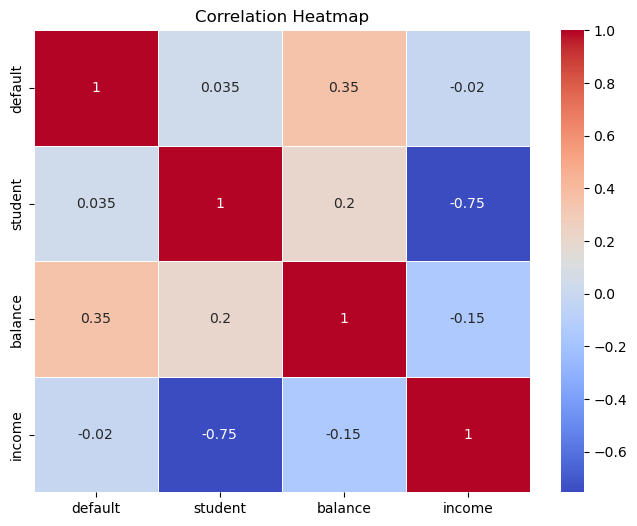

In [77]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(),annot=True,cmap="coolwarm",linewidth=0.5)
plt.title("Correlation Heatmap")
plt.show()

# Understand how strongly features (balance, income, student status) are related to default.
# 1️⃣ Default vs Balance (0.35)
# Moderate positive correlation 📈

# This means that as balance increases, the likelihood of defaulting also increases.

# This suggests that credit card users with higher balances are more likely to default.

# 2️⃣ Default vs Income (-0.02)
# Very weak negative correlation

# Income does not significantly impact default probability in your dataset.

# This suggests that income alone may not be a strong predictor of default.

# 3️⃣ Default vs Student (0.035)
# Almost no correlation

# Being a student has no significant impact on default probability.

# 4️⃣ Student vs Income (-0.75)
# Strong negative correlation 🔵

# This means students generally have lower incomes compared to non-students.

# This makes sense, as students typically do not have full-time jobs.

# 5️⃣ Balance vs Income (-0.15)
# Weak negative correlation

# Suggests that people with lower incomes tend to have slightly higher balances.

# But it's not strong enough to be a major factor.

# 6️⃣ Student vs Balance (0.2)
# Weak positive correlation

# Students tend to have slightly higher balances, but the effect is not strong.

# Pairplot

sns.pairplot(df, hue="default", diag_kind="kde", palette="coolwarm")
plt.show()

# Your pairplot helps visualize relationships between numerical variables in your dataset, with points colored by the default status (0 = No Default, 1 = Default).

# 📊 Observations from the Pairplot:
# 1️⃣ Balance vs Default:

# Users with higher balances tend to default more (orange points on the upper side).

# This reinforces the correlation heatmap observation that balance is a strong predictor of default.

# 2️⃣ Income vs Default:

# No clear pattern between income and default.

# Users from both low and high-income groups have similar default rates.

# 3️⃣ Student vs Default:

# Students (1) and non-students (0) show no major difference in default trends.

# This aligns with the heatmap’s weak correlation (0.035).

# 4️⃣ Balance vs Income:

# Defaulting users are spread across different income levels, but most defaults occur at higher balances.

# Income alone is not a strong predictor, but balance could be.